# Ishan Sarda
## A-A2-23
## ML-Lab-5

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_score,StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import(accuracy_score, precision_score,recall_score,f1_score,confusion_matrix,classification_report)

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


df = pd.read_csv("diabetes.csv")
print("shape:",df.shape)
df.head()
zero_columns = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
zero_counts = (df[zero_columns] == 0).sum()
print("Zero Counts:")
print(zero_counts)

shape: (768, 9)
Zero Counts:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [3]:
df_clean=df.copy()
df_clean[zero_columns] = df_clean[zero_columns].replace(0,np.nan)
print("Missing values after  replacing invalid zeroes: ")
print(df_clean.isnull().sum())

Missing values after  replacing invalid zeroes: 
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [4]:
for col in zero_columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

print("Missing values after imputation:")
print(df_clean.isnull().sum())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [5]:
x = df_clean.drop("Outcome",axis=1)
y = df_clean["Outcome"]

print("Shape of x:",x.shape)
print("Shape of y:",y.shape)


Shape of x: (768, 8)
Shape of y: (768,)


In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)
print("Shape of x_train:",x_train.shape[0])
print("Shape of x_test:",x_test.shape[0])



Shape of x_train: 614
Shape of x_test: 154


In [7]:
print("Training distribution: ")
print(y_train.value_counts(normalize=True))
print("Testing distribution: ")
print(y_test.value_counts(normalize=True))

Training distribution: 
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Testing distribution: 
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [8]:
scaler=StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [9]:
scaler.fit_transform(x_test)

array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]])

In [10]:
scaler.transform(x_test)

array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]])

In [14]:
comparison = pd.DataFrame({"Original Mean ":x_train.mean(),"Original Std":x_train.std(),"Scaled Mean ":x_train_scaled.mean(axis=0),"Scaled Std":x_train_scaled.std(axis=0)})
display(comparison)

,Original Mean,Original Std,Scaled Mean,Scaled Std
Pregnancies,3.819218,3.314148,-6.943414e-17,1.0
Glucose,121.671010,30.003794,-1.099374e-16,1.0
BloodPressure,72.140065,12.275119,3.095606e-16,1.0
SkinThickness,29.042345,8.891855,-3.471707e-17,1.0
Insulin,137.705212,78.764767,-4.339634e-18,1.0
BMI,32.446743,6.824142,-1.148556e-15,1.0
DiabetesPedigreeFunction,0.477428,0.330300,-1.099374e-16,1.0
Age,33.366450,11.833438,-1.084908e-16,1.0


In [15]:
K=5

In [16]:
knn = KNeighborsClassifier(n_neighbors=K)
knn.fit(x_train_scaled,y_train)

KNeighborsClassifier()

In [21]:
y_pred= knn.predict(x_test_scaled)
print("Predictions:")
print(y_pred[:20])

Predictions:
[1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0]


In [19]:
y_proba = knn.predict_proba(x_test_scaled)
print("Prediction probabilities:")
print(y_proba[:20])

Prediction probabilities:
[[0.4 0.6]
 [0.8 0.2]
 [0.8 0.2]
 [0.4 0.6]
 [1.  0. ]
 [0.8 0.2]
 [0.8 0.2]
 [0.2 0.8]
 [1.  0. ]
 [0.4 0.6]
 [0.6 0.4]
 [0.4 0.6]
 [1.  0. ]
 [1.  0. ]
 [1.  0. ]
 [0.4 0.6]
 [0.2 0.8]
 [1.  0. ]
 [0.  1. ]
 [0.8 0.2]]


In [20]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
precision = precision_score(y_test,y_pred)
print("Precision:",precision)
recall = recall_score(y_test,y_pred)
print("Recall:",recall)
f1 = f1_score(y_test,y_pred)
print("F1 Score:",f1)

Accuracy: 0.7532467532467533
Precision: 0.66
Recall: 0.6111111111111112
F1 Score: 0.6346153846153846


In [22]:
print(classification_report(y_test,y_pred, target_names=["No Diabetes","Diabetes"]))

              precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81       100
    Diabetes       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [23]:
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[83 17]
 [21 33]]


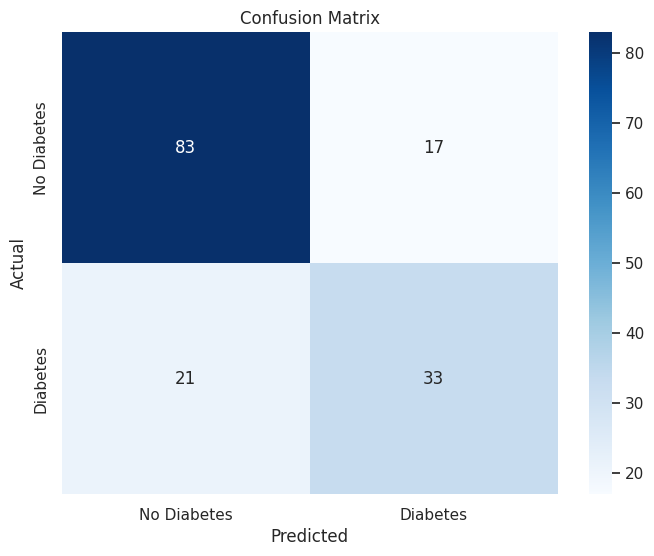

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["No Diabetes","Diabetes"],yticklabels=["No Diabetes","Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
k_values= range(1,31)
train_accuracy=[]
test_accuracy=[]

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train_scaled,y_train)
    train_accuracy.append(model.score(x_train_scaled,y_train))
    test_accuracy.append(model.score(x_test_scaled,y_test))

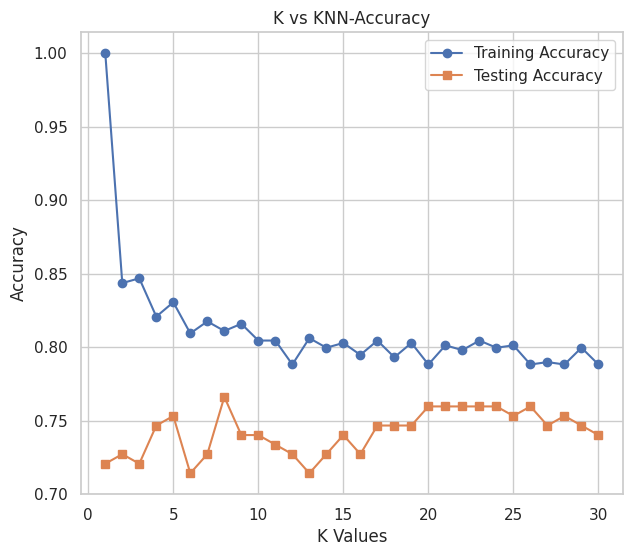

In [31]:
plt.figure(figsize=(7,6))
plt.plot(k_values,train_accuracy,marker="o",label="Training Accuracy")
plt.plot(k_values,test_accuracy,marker="s",label="Testing Accuracy")
plt.xlabel("K Values")
plt.ylabel("Accuracy")
plt.title("K vs KNN-Accuracy")
plt.legend()
plt.show()

In [32]:
best_k_accuracy= k_values[np.argmax(test_accuracy)]
print("Best K value:",best_k_accuracy)
print("Best Accuracy:",max(test_accuracy))

Best K value: 8
Best Accuracy: 0.7662337662337663


In [33]:
cv = StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
cv_scores= []
for k in range(1,31):
  model= KNeighborsClassifier(n_neighbors=k)
  scores = cross_val_score(model,x_train_scaled,y_train,cv=cv,scoring="accuracy")
  cv_scores.append(scores.mean())

In [34]:
best_k_cv= np.argmax(cv_scores) + 1
print("Best K value based on Cross Validation:",best_k_cv)
print("Best CV Accuracy based on Cross Validation:",max(cv_scores))

Best K value based on Cross Validation: 24
Best CV Accuracy based on Cross Validation: 0.776969857218403


In [36]:
from scipy.spatial.distance import euclidean
param_grid = {"n_neighbors":list(range(1,31,2)), "weights":["uniform","distance"], "metric":["euclidean","manhattan","minkowski"],"p":[1,2]}
grid_search = GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,scoring="accuracy")
grid_search.fit(x_train_scaled,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21,
                                         23, 25, 27, 29],
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [37]:
print("Best Parameters:",grid_search.best_params_)
print("Best cross-validation score:",grid_search.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 19, 'p': 1, 'weights': 'uniform'}
Best cross-validation score: 0.7769025723044115


In [38]:
best_knn = grid_search.best_estimator_
print("Best KNN Model:")
print(best_knn)


Best KNN Model:
KNeighborsClassifier(metric='euclidean', n_neighbors=19, p=1)


In [39]:
final_predictions = best_knn.predict(x_test_scaled)
final_probabilities = best_knn.predict_proba(x_test_scaled)[:,1]

In [41]:
final_accuracy = accuracy_score(y_test,final_predictions)
final_precision = precision_score(y_test,final_predictions)
final_recall = recall_score(y_test,final_predictions)
final_f1 = f1_score(y_test,final_predictions)

print("Final Accuracy:",final_accuracy)
print("Final Precision:",final_precision)
print("Final Recall:",final_recall)
print("Final F1 Score:",final_f1)

Final Accuracy: 0.7467532467532467
Final Precision: 0.6666666666666666
Final Recall: 0.5555555555555556
Final F1 Score: 0.6060606060606061
